### **Gaussian Processing with GPyTorch**

1. LOADING & PREPROCESSING DATA
Running on Device: cuda

2. INITIALIZING MODELLIST GP & FIXED NOISE LIKELIHOODS

3. TRAINING INDEPENDENT GPs SIMULTANEOUSLY
Epoch  50/3000 - Joint Loss: 0.2442
Epoch 100/3000 - Joint Loss: 0.2317
Epoch 150/3000 - Joint Loss: 0.2284
Epoch 200/3000 - Joint Loss: 0.2267
Epoch 250/3000 - Joint Loss: 0.2256
Epoch 300/3000 - Joint Loss: 0.2250
Epoch 350/3000 - Joint Loss: 0.2245
Epoch 400/3000 - Joint Loss: 0.2240
Epoch 450/3000 - Joint Loss: 0.2236
Epoch 500/3000 - Joint Loss: 0.2232
Epoch 550/3000 - Joint Loss: 0.2227
Epoch 600/3000 - Joint Loss: 0.2219
Epoch 650/3000 - Joint Loss: 0.2211
Epoch 700/3000 - Joint Loss: 0.2208
Epoch 750/3000 - Joint Loss: 0.2205
Epoch 800/3000 - Joint Loss: 0.2204
Epoch 850/3000 - Joint Loss: 0.2203
Epoch 900/3000 - Joint Loss: 0.2202
Epoch 950/3000 - Joint Loss: 0.2201
Epoch 1000/3000 - Joint Loss: 0.2201
Epoch 1050/3000 - Joint Loss: 0.2200
Epoch 1100/3000 - Joint Loss: 0.2200
Epoch 1150/3000 - Joint Loss: 0.2200
Epoch 1200/3

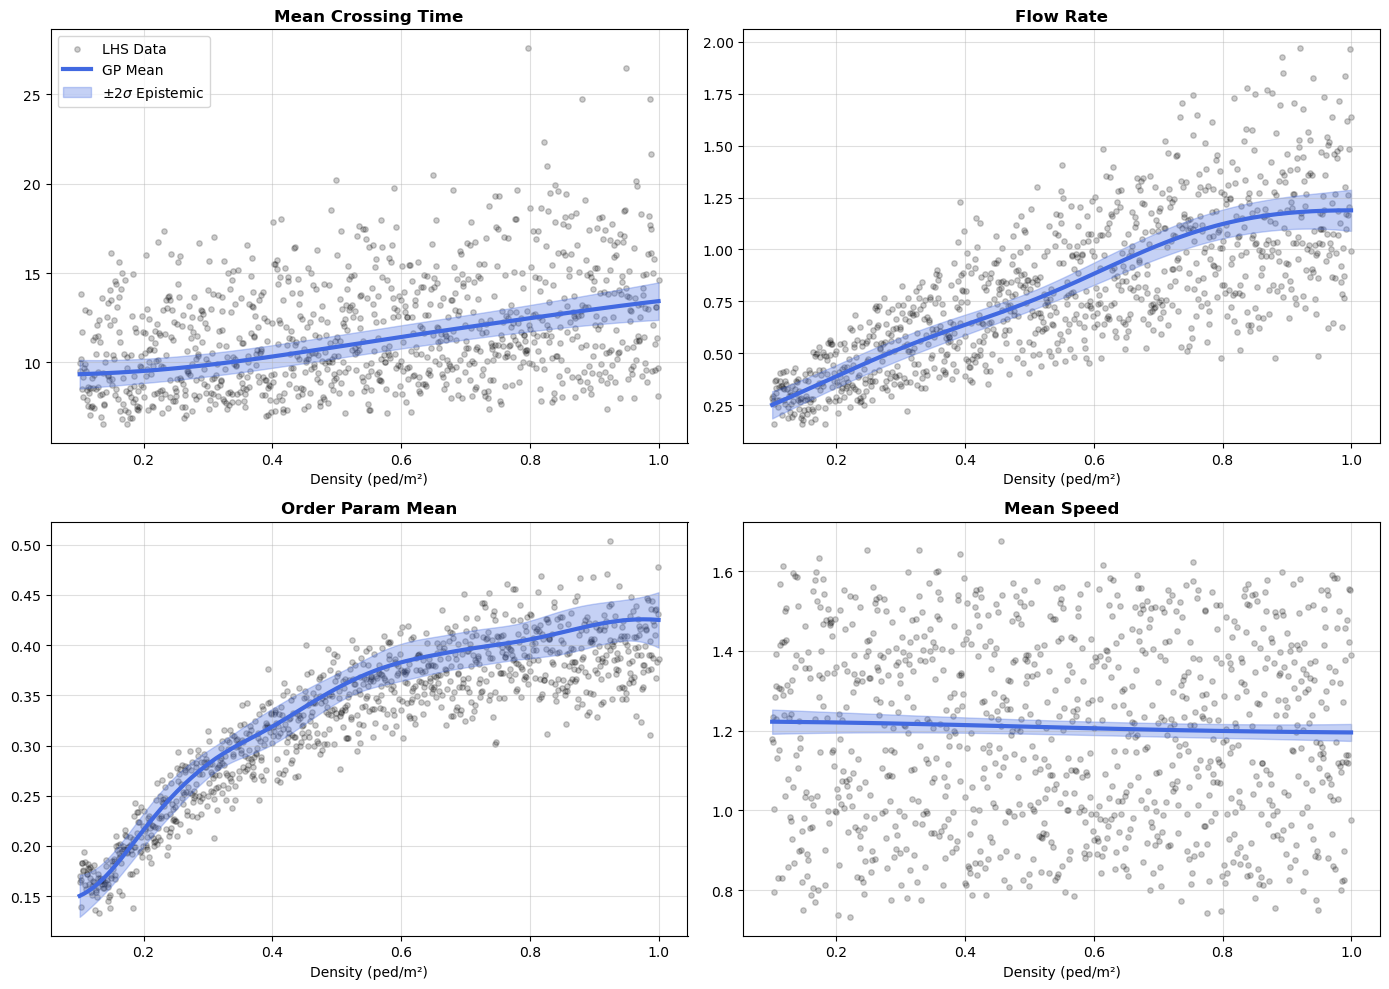

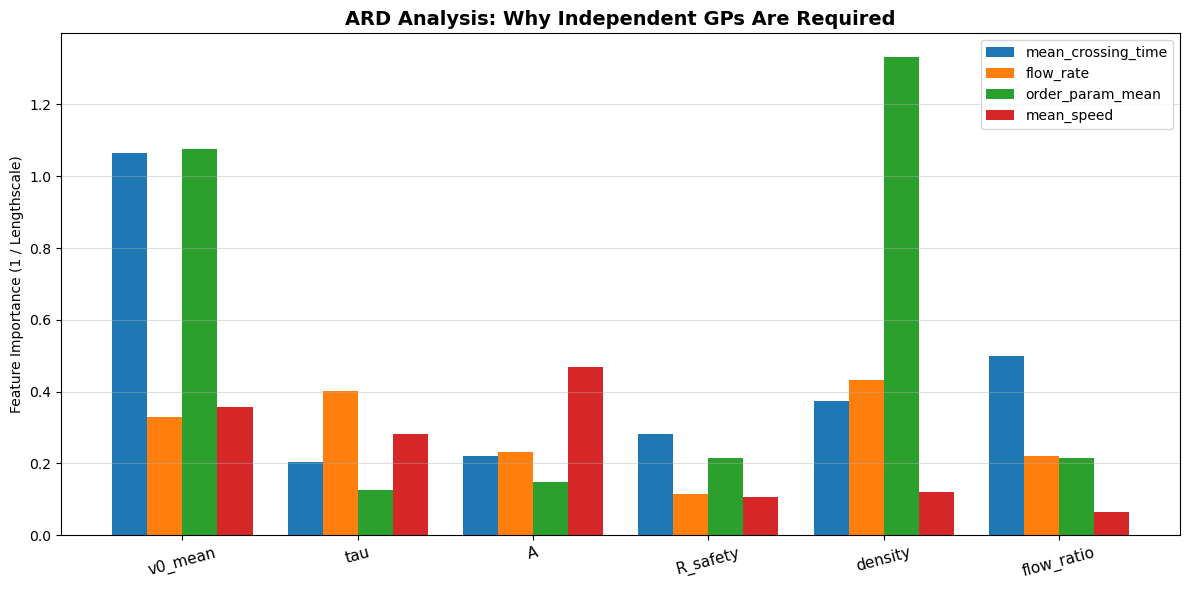

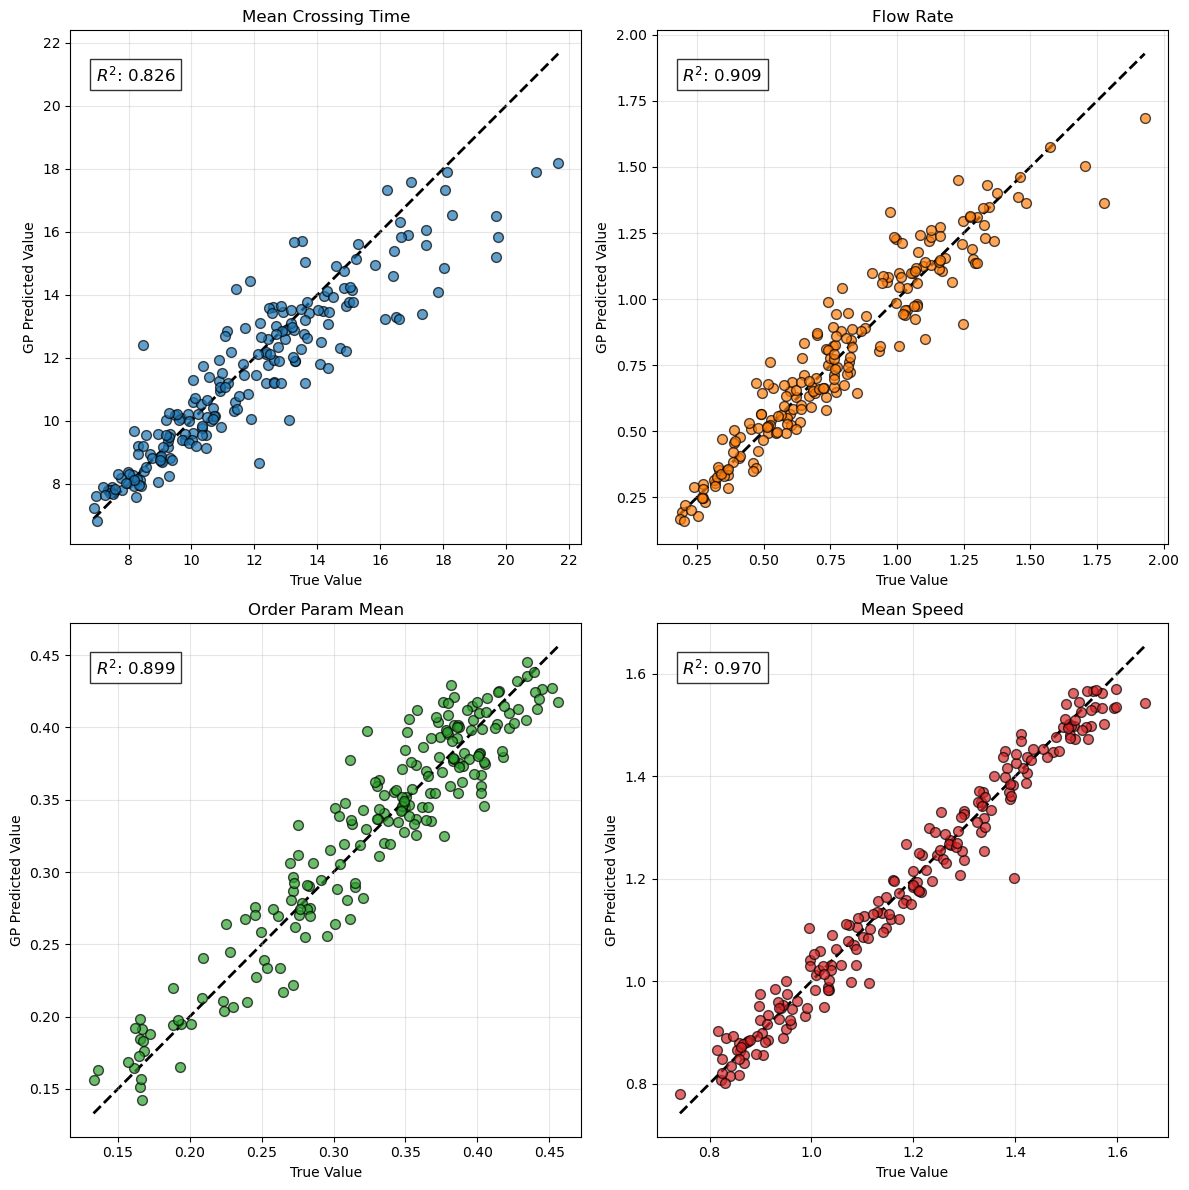

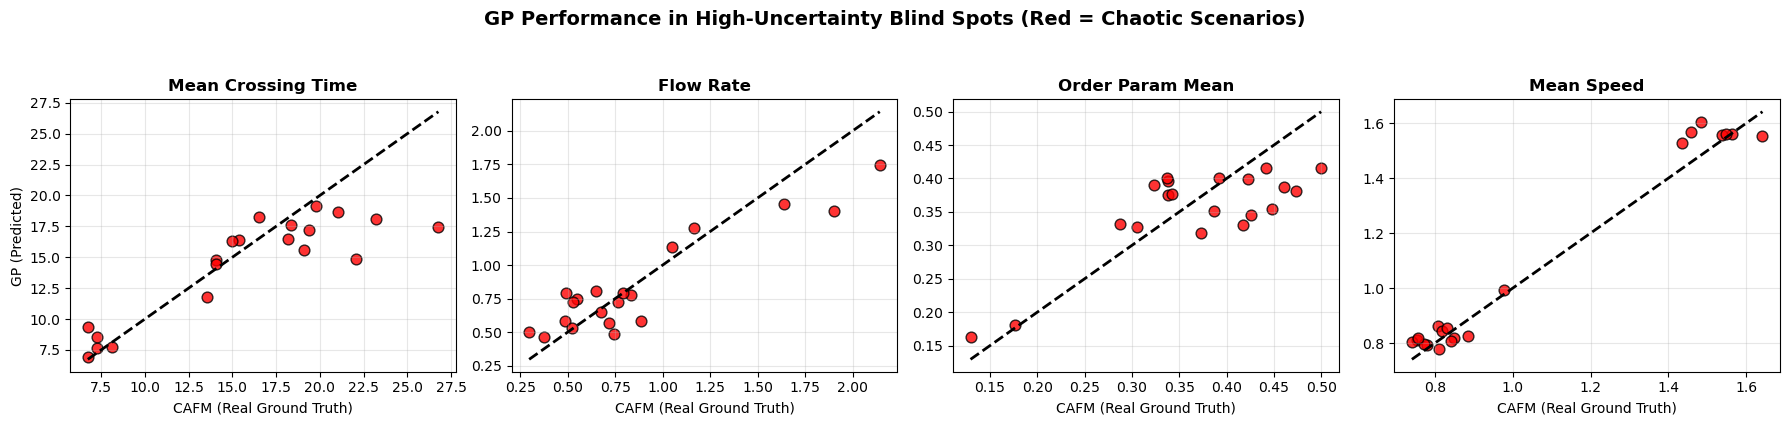

In [7]:
import numpy as np
import time
import torch
import gpytorch
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
import warnings
from cafm_sim_v3 import SimParams, run_simulation
import pandas as pd
import torch
import numpy as np
from scipy.stats import qmc

warnings.filterwarnings("ignore")

# ==========================================
# 1. GPYTORCH KERNEL & MODEL ARCHITECTURE
# ==========================================
class HeteroscedasticTaskGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(HeteroscedasticTaskGP, self).__init__(train_x, train_y, likelihood)
        # Constant mean for standard scaled data
        self.mean_module = gpytorch.means.ConstantMean()
        # Matern 5/2 with Automatic Relevance Determination (ARD) for 6 inputs
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(nu=2.5, ard_num_dims=6)
        )

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# ==========================================
# 2. MAIN PIPELINE
# ==========================================
def run_gpytorch_pipeline(data_path):
    print("="*60)
    print("1. LOADING & PREPROCESSING DATA")
    print("="*60)
    
    # Load Data
    data = np.load(data_path)
    X_raw, Y_raw, Y_std_raw = data['X'], data['Y'], data['Y_std']
    param_names = data['param_names']
    output_names = data['output_names']
    
    num_tasks = Y_raw.shape[1]
    density_idx = 4 # Index of 'density' in param_names
    
    # Remove NaNs
    valid_mask = ~np.isnan(Y_raw).any(axis=1)
    X_clean = X_raw[valid_mask]
    Y_clean = Y_raw[valid_mask]
    Y_std_clean = Y_std_raw[valid_mask]

    # Train/Test Split
    X_train, X_test, Y_train, Y_test, Y_std_train, Y_std_test = train_test_split(
        X_clean, Y_clean, Y_std_clean, test_size=0.2, random_state=42
    )

    # Scaling
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    scaler_Y = StandardScaler()
    Y_train_scaled = scaler_Y.fit_transform(Y_train)
    Y_test_scaled = scaler_Y.transform(Y_test)
    
    # CRITICAL: Scale the standard deviations!
    Y_std_train_scaled = Y_std_train / scaler_Y.scale_
    Y_var_train_scaled = Y_std_train_scaled ** 2  # Variance is std^2

    # Convert to PyTorch Tensors
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on Device: {device}")
    
    train_x_t = torch.FloatTensor(X_train_scaled).to(device)
    test_x_t = torch.FloatTensor(X_test_scaled).to(device)
    
    print("\n" + "="*60)
    print("2. INITIALIZING MODELLIST GP & FIXED NOISE LIKELIHOODS")
    print("="*60)
    
    models = []
    likelihoods = []
    
    for i in range(num_tasks):
        train_y_t = torch.FloatTensor(Y_train_scaled[:, i]).to(device)
        train_noise_t = torch.FloatTensor(Y_var_train_scaled[:, i]).to(device)
        
        # Inject empirical noise (Y_var) directly into the likelihood
        likelihood = gpytorch.likelihoods.FixedNoiseGaussianLikelihood(
            noise=train_noise_t, learn_additional_noise=False
        ).to(device)
        
        model = HeteroscedasticTaskGP(train_x_t, train_y_t, likelihood).to(device)
        
        models.append(model)
        likelihoods.append(likelihood)

    # Wrap into ModelList
    model_list = gpytorch.models.IndependentModelList(*models)
    likelihood_list = gpytorch.likelihoods.LikelihoodList(*likelihoods)

    print("\n" + "="*60)
    print("3. TRAINING INDEPENDENT GPs SIMULTANEOUSLY")
    print("="*60)
    
    model_list.train()
    likelihood_list.train()
    
    optimizer = torch.optim.Adam(model_list.parameters(), lr=0.09)
    mll = gpytorch.mlls.SumMarginalLogLikelihood(likelihood_list, model_list)
    
    epochs = 3000
    for i in range(epochs):
        optimizer.zero_grad()
        output = model_list(*[train_x_t for _ in range(num_tasks)])
        loss = -mll(output, [torch.FloatTensor(Y_train_scaled[:, t]).to(device) for t in range(num_tasks)])
        loss.backward()
        optimizer.step()
        
        if (i+1) % 50 == 0:
            print(f"Epoch {i+1:>3}/{epochs} - Joint Loss: {loss.item():.4f}")

    print("\n" + "="*60)
    print("4. EVALUATION & INFERENCE")
    print("="*60)
    
    model_list.eval()
    likelihood_list.eval()

    # --- Metrics ---
    # FIX: We bypass the LikelihoodList completely because E[y] = E[f]. 
    # This prevents any unexpected kwarg errors during inference.
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        model_outputs = model_list(*[test_x_t for _ in range(num_tasks)])
        test_preds = [out.mean.cpu().numpy() for out in model_outputs]
    
    test_mean_scaled = np.column_stack(test_preds)
    test_mean_real = scaler_Y.inverse_transform(test_mean_scaled)
    
    print(f"{'Task':<25} | {'R2 Score':<8} | {'RMSE':<8}")
    print("-" * 50)
    for i, name in enumerate(output_names):
        r2 = r2_score(Y_test[:, i], test_mean_real[:, i])
        rmse = root_mean_squared_error(Y_test[:, i], test_mean_real[:, i])
        print(f"{name:<25} | {r2:.4f}   | {rmse:.4f}")

    print("\n" + "="*60)
    print("5. VISUALIZATION: PARTIAL DEPENDENCY & ARD")
    print("="*60)

    # ----------------------------------------------------
    # PLOT 1: PARTIAL DEPENDENCE (ALL 4 TASKS)
    # ----------------------------------------------------
    n_sweep = 150
    X_sweep = np.tile(np.mean(X_clean, axis=0), (n_sweep, 1))
    den_sweep = np.linspace(np.min(X_clean[:, density_idx]), np.max(X_clean[:, density_idx]), n_sweep)
    X_sweep[:, density_idx] = den_sweep

    X_sweep_scaled_t = torch.FloatTensor(scaler_X.transform(X_sweep)).to(device)

    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        sweep_model_preds = model_list(*[X_sweep_scaled_t for _ in range(num_tasks)])

    fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
    axes1 = axes1.flatten()

    for i in range(num_tasks):
        mean_scaled = sweep_model_preds[i].mean.cpu().numpy()
        var_scaled  = sweep_model_preds[i].variance.cpu().numpy()
        std_scaled  = np.sqrt(var_scaled)

        # Correct inverse transform for scaled Gaussian
        mean_real = (mean_scaled * scaler_Y.scale_[i]) + scaler_Y.mean_[i]
        std_real  = std_scaled * scaler_Y.scale_[i]   # std scales linearly

        ax = axes1[i]
        ax.scatter(X_clean[:, density_idx], Y_clean[:, i],
                color='black', alpha=0.2, s=15, label='LHS Data')
        ax.plot(den_sweep, mean_real, color='royalblue', lw=3, label='GP Mean')
        ax.fill_between(den_sweep,
                        mean_real - 2*std_real,
                        mean_real + 2*std_real,
                        color='royalblue', alpha=0.3, label=r'$\pm 2\sigma$ Epistemic')
        ax.set_title(output_names[i].replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel("Density (ped/m²)")
        if i == 0:
            ax.legend()
        ax.grid(True, alpha=0.4)

    plt.tight_layout()
    plt.savefig("plot_A_multi_task_partial_dependence.png", dpi=300)
    print("Saved: plot_A_multi_task_partial_dependence.png")

    # ----------------------------------------------------
    # PLOT 2: ARD LENGTH-SCALE ANALYSIS
    # ----------------------------------------------------
    lengthscales = np.zeros((num_tasks, len(param_names)))
    for i, model in enumerate(models):
        ls = model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten()
        lengthscales[i] = ls

    importance = 1.0 / lengthscales

    fig2, ax2 = plt.subplots(figsize=(12, 6))
    x_pos = np.arange(len(param_names))
    width = 0.2
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    for i in range(num_tasks):
        ax2.bar(x_pos + (i * width), importance[i], width,
                label=output_names[i], color=colors[i])

    ax2.set_xticks(x_pos + 1.5 * width)
    ax2.set_xticklabels(param_names, rotation=15, fontsize=11)
    ax2.set_ylabel("Feature Importance (1 / Lengthscale)")
    ax2.set_title("ARD Analysis: Why Independent GPs Are Required", fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig("plot_B_ard_feature_importance.png", dpi=300)
    print("Saved: plot_B_ard_feature_importance.png")

    # ----------------------------------------------------
    # PLOT 3: PARITY PLOTS
    # ----------------------------------------------------
    fig3, axes3 = plt.subplots(2, 2, figsize=(12, 12))
    axes3 = axes3.flatten()

    for i in range(num_tasks):
        ax = axes3[i]
        real = Y_test[:, i]
        pred = test_mean_real[:, i]

        min_val, max_val = np.min(real), np.max(real)
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, zorder=1)
        ax.scatter(real, pred, color=colors[i], alpha=0.7, edgecolor='k', s=50, zorder=2)
        ax.set_title(output_names[i].replace('_', ' ').title(), fontsize=12)
        ax.set_xlabel("True Value")
        ax.set_ylabel("GP Predicted Value")
        ax.grid(True, alpha=0.3)

        r2_i = r2_score(real, pred)   
        ax.text(0.05, 0.90, f'$R^2$: {r2_i:.3f}',
                transform=ax.transAxes, fontsize=12,
                bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig("plot_C_parity_evaluation.png", dpi=300)
    print("Saved: plot_C_parity_evaluation.png")

    return model_list, likelihood_list, scaler_X, scaler_Y, device, output_names

# ==========================================
# 3. BENCHMARKING PIPELINE (CAFM vs GP)
# ==========================================
def density_to_counts(density, flow_ratio):
    """Helper function to convert density to agent counts for CAFM"""
    MEASURE_AREA = 30.0 # 10m x 3m 
    N_total  = int(np.clip(round(density * MEASURE_AREA), 4, 60))
    n_minor  = int(round(flow_ratio * N_total))
    n_major  = N_total - n_minor
    if n_minor == 0 and flow_ratio > 0:
        n_minor = 2; n_major = max(2, N_total - 2)
    if n_major == 0:
        n_major = 2; n_minor = max(2, N_total - 2)
    return n_major, n_minor

def run_cafm_vs_gp_benchmark(model_list, likelihood_list, scaler_X, scaler_Y, device, output_names):
    print("\n" + "="*70)
    print("🚀 THE ULTIMATE RACE: CAFM SIMULATOR vs GP SURROGATE 🚀")
    print("="*70)
    
    # Generate 5 random testing scenarios within parameter bounds
    test_scenarios = [
        [1.30, 0.50, 20.0, 1.20, 0.40, 0.10],
        [1.00, 0.60, 30.0, 1.40, 0.80, 0.30],
        [1.50, 0.35, 15.0, 1.00, 0.20, 0.00],
        [0.90, 0.70, 35.0, 1.50, 0.95, 0.45],
        [1.25, 0.45, 25.0, 1.10, 0.60, 0.25]
    ]
    
    num_tasks = len(output_names)
    
    # ---------------------------------------------------------
    # RUN ORIGINAL CAFM SIMULATOR
    # ---------------------------------------------------------
    print("Running Original CAFM Simulator (ODE Solver)...")
    cafm_results = []
    cafm_times = []
    
    for i, config in enumerate(test_scenarios):
        v0_mean, tau, A, R_safety, density, flow_ratio = config
        n_major, n_minor = density_to_counts(density, flow_ratio)
        
        p = SimParams(
            n_major=n_major, n_minor=n_minor, v0_mean=float(v0_mean), 
            tau=float(tau), A=float(A), R_safety=float(R_safety), 
            R_danger=float(R_safety * 0.5), seed=42+i
        )
        
        t0 = time.time()
        res = run_simulation(p)  # This solves the actual ODEs
        t1 = time.time()
        
        cafm_times.append(t1 - t0)
        cafm_results.append([res[name] for name in output_names])
        print(f"  Scenario {i+1} completed in {(t1-t0):.3f} seconds")
        
    total_cafm_time = sum(cafm_times)
    
    # ---------------------------------------------------------
    # RUN GPYTORCH SURROGATE
    # ---------------------------------------------------------
    print("\nRunning GPyTorch Surrogate (Inference)...")
    
    X_test_scaled = scaler_X.transform(test_scenarios)
    X_tensor = torch.FloatTensor(X_test_scaled).to(device)
    
    model_list.eval()
    likelihood_list.eval()
    
    t0_gp = time.time()
    # FIX: Extract means directly from model_list to avoid any Likelihood kwarg issues
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        model_outputs = model_list(*[X_tensor for _ in range(num_tasks)])
        gp_preds = [out.mean.cpu().numpy() for out in model_outputs]
            
    gp_means_scaled = np.column_stack(gp_preds)
    gp_results_real = scaler_Y.inverse_transform(gp_means_scaled)
    t1_gp = time.time()
    
    total_gp_time = t1_gp - t0_gp
    print(f"  All {len(test_scenarios)} scenarios completed in {total_gp_time:.5f} seconds")
    
    # ---------------------------------------------------------
    # PRINT COMPARISON REPORT
    # ---------------------------------------------------------
    print("\n" + "="*70)
    print("🏆 BENCHMARK RESULTS & PREDICTION ACCURACY 🏆")
    print("="*70)
    
    speedup_factor = total_cafm_time / total_gp_time
    print(f"Total CAFM Time : {total_cafm_time:.3f} seconds")
    print(f"Total GP Time   : {total_gp_time:.5f} seconds")
    print(f"Speedup Factor  : {speedup_factor:,.0f}x FASTER!")
    print("-" * 70)
    
    for i in range(len(test_scenarios)):
        print(f"\nScenario {i+1} | Density: {test_scenarios[i][4]:.2f} | Flow Ratio: {test_scenarios[i][5]:.2f}")
        print(f"  Metric              | CAFM (Real) | GP (Predicted) | Error")
        for j, name in enumerate(output_names):
            real_val = cafm_results[i][j]
            pred_val = gp_results_real[i][j]
            error_pct = abs(real_val - pred_val) / (abs(real_val) + 1e-6) * 100
            print(f"  {name:<19} | {real_val:>11.3f} | {pred_val:>14.3f} | {error_pct:>4.1f}%")



# =============================
# Most caotic Points
# ==============================





def active_learning_radar(model_list, scaler_X, device, param_names, n_candidates=10000, percentile_threshold=95):
    print("\n" + "="*70)
    print("📡 ACTIVE LEARNING RADAR: EXTRACTING ALL CHAOTIC ZONES 📡")
    print("="*70)
    
    # 1. Define Parameter Bounds
    bounds = {
        "v0_mean":  (0.80, 1.60),
        "tau":      (0.30, 0.80),
        "A":        (10.0, 40.0),
        "R_safety": (0.80, 1.60),
        "density":  (0.10, 1.00),
        "flow_ratio":(0.00, 0.50)
    }
    lowers = np.array([bounds[name][0] for name in param_names])
    uppers = np.array([bounds[name][1] for name in param_names])
    
    # 2. Generate 10,000 unsimulated candidate points
    print(f"Scanning {n_candidates:,} hypothetical 6D configurations...")
    sampler = qmc.LatinHypercube(d=len(param_names), strength=1, seed=99)
    X_pool_unscaled = qmc.scale(sampler.random(n_candidates), lowers, uppers)
    
    X_pool_scaled = scaler_X.transform(X_pool_unscaled)
    X_pool_tensor = torch.FloatTensor(X_pool_scaled).to(device)
    
    # 3. Query the GP for Epistemic Uncertainty
    for m in model_list.models:
        m.eval()
    num_tasks = len(model_list.models)
    
    total_doubt_score = np.zeros(n_candidates)
    
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        pool_outputs = model_list(*[X_pool_tensor for _ in range(num_tasks)])
        
        for i in range(num_tasks):
            variance_i = pool_outputs[i].variance.cpu().numpy()
            
            # Normalize so each task contributes equally to the "doubt score"
            min_v, max_v = variance_i.min(), variance_i.max()
            normalized_variance = (variance_i - min_v) / (max_v - min_v + 1e-9)
            total_doubt_score += normalized_variance

    # 4. Filter ALL points above the Uncertainty Threshold
    # Default is 95th percentile (Top 5% most uncertain points of the space)
    threshold_value = np.percentile(total_doubt_score, percentile_threshold)
    chaotic_indices = np.where(total_doubt_score >= threshold_value)[0]
    
    print(f"\n⚠️ FOUND {len(chaotic_indices)} POINTS EXCEEDING NORMAL UNCERTAINTY THRESHOLD!")
    print(f"Threshold Type: Top {100-percentile_threshold}% of chaotic zones.")
    print("-" * 70)
    
    # Extract those chaotic points
    chaotic_configs = X_pool_unscaled[chaotic_indices]
    chaotic_scores = total_doubt_score[chaotic_indices]
    
    # Sort them from highest doubt to lowest doubt
    sorted_order = np.argsort(chaotic_scores)[::-1]
    chaotic_configs = chaotic_configs[sorted_order]
    chaotic_scores = chaotic_scores[sorted_order]
    
    # Show top 5 just for a quick terminal preview
    header = " | ".join([f"{name:>10}" for name in param_names])
    print(f"Preview of Top 5:\nRank | Score | {header}")
    print("-" * 70)
    for rank in range(min(5, len(chaotic_configs))):
        config_str = " | ".join([f"{val:>10.3f}" for val in chaotic_configs[rank]])
        print(f" #{rank+1:<2} | {chaotic_scores[rank]:.2f}  | {config_str}")
        
    # 5. Save ALL chaotic points to a CSV file for the CAFM Simulator
    df = pd.DataFrame(chaotic_configs, columns=param_names)
    df['uncertainty_score'] = chaotic_scores
    csv_filename = "active_learning_targets.csv"
    df.to_csv(csv_filename, index=False)
    print("\n" + "-" * 70)
    print(f"✅ All {len(chaotic_indices)} points successfully saved to '{csv_filename}'")
    print("Next step: Run these exact parameters in your CAFM ODE solver.")
    print("-" * 70)
    
    return chaotic_configs

# ==========================================
# 4. BLIND SPOT ANALYSIS (CAFM vs GP)
# ==========================================
import pandas as pd

def analyze_blind_spots(csv_path, model_list, scaler_X, scaler_Y, device, output_names, top_k=20):
    print("\n" + "="*70)
    print(f"🔬 BLIND SPOT ANALYSIS: TESTING TOP {top_k} CHAOTIC ZONES 🔬")
    print("="*70)
    
    # 1. Load the chaotic points saved by the Radar
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"File {csv_path} not found. Please run the Active Learning Radar first.")
        return
        
    # Take the absolute most uncertain points
    df = df.head(top_k)
    param_names = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
    X_chaotic = df[param_names].values
    
    # 2. Run CAFM Simulator to get the Ground Truth
    print(f"Running CAFM Simulator on {top_k} highly uncertain points...")
    cafm_results = []
    
    for i, config in enumerate(X_chaotic):
        v0_mean, tau, A, R_safety, density, flow_ratio = config
        n_major, n_minor = density_to_counts(density, flow_ratio)
        p = SimParams(
            n_major=n_major, n_minor=n_minor, v0_mean=float(v0_mean), 
            tau=float(tau), A=float(A), R_safety=float(R_safety), 
            R_danger=float(R_safety * 0.5), seed=999+i # Fresh seed for testing
        )
        
        t0 = time.time()
        res = run_simulation(p)
        t1 = time.time()
        
        cafm_results.append([res[name] for name in output_names])
        print(f"  [{i+1:>2}/{top_k}] CAFM Simulation Complete. ({(t1-t0):.2f}s)", end="\r")
        
    print("\nCAFM runs finished.")
    cafm_results = np.array(cafm_results)
    
    # 3. Run GP Surrogate Inference on the exact same points
    print("Running GP Inference on the blind spots...")
    X_tensor = torch.FloatTensor(scaler_X.transform(X_chaotic)).to(device)
    num_tasks = len(output_names)
    
    model_list.eval()
    with torch.no_grad(), gpytorch.settings.fast_pred_var():
        model_outputs = model_list(*[X_tensor for _ in range(num_tasks)])
        gp_preds = [out.mean.cpu().numpy() for out in model_outputs]
        
    gp_results_real = scaler_Y.inverse_transform(np.column_stack(gp_preds))
    
    # 4. Deep Error Analysis
    print("\n" + "="*70)
    print("💥 WHERE IS THE MODEL FAILING? (ERROR REPORT) 💥")
    print("="*70)
    
    for j, name in enumerate(output_names):
        real_vals = cafm_results[:, j]
        pred_vals = gp_results_real[:, j]
        
        abs_errors = np.abs(real_vals - pred_vals)
        pct_errors = abs_errors / (np.abs(real_vals) + 1e-6) * 100
        
        mean_pct_error = np.mean(pct_errors)
        max_pct_error = np.max(pct_errors)
        worst_idx = np.argmax(pct_errors)
        worst_config = X_chaotic[worst_idx]
        
        print(f"Task: {name.upper()}")
        print(f"  Average Error in Blind Spots : {mean_pct_error:.2f}%")
        print(f"  Maximum Error Observed       : {max_pct_error:.2f}%")
        print(f"  Worst Failure Condition      : Density={worst_config[4]:.2f}, Flow Ratio={worst_config[5]:.2f}, Speed={worst_config[0]:.2f}")
        print("-" * 70)
        
    # 5. Quick Visualization for the Blind Spots
    # 5. Detailed Printout for Top 20 Chaotic Zones
    print("\n" + "="*70)
    print("📋 DETAILED PREDICTIONS FOR TOP CHAOTIC ZONES 📋")
    print("="*70)
    
    for i in range(len(X_chaotic)):
        config = X_chaotic[i]
        print(f"\nChaotic Zone #{i+1} | Density: {config[4]:.2f} | Flow Ratio: {config[5]:.2f} | Speed: {config[0]:.2f}")
        print(f"  Metric              | CAFM (Real) | GP (Predicted) | Error")
        for j, name in enumerate(output_names):
            real_val = cafm_results[i, j]
            pred_val = gp_results_real[i, j]
            error_pct = abs(real_val - pred_val) / (abs(real_val) + 1e-6) * 100
            print(f"  {name:<19} | {real_val:>11.3f} | {pred_val:>14.3f} | {error_pct:>4.1f}%")

    # 6. Quick Visualization for the Blind Spots (Your existing plot code)
    fig, axes = plt.subplots(1, num_tasks, figsize=(18, 4))
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for j, name in enumerate(output_names):
        ax = axes[j]
        real = cafm_results[:, j]
        pred = gp_results_real[:, j]
        
        min_v, max_v = min(np.min(real), np.min(pred)), max(np.max(real), np.max(pred))
        ax.plot([min_v, max_v], [min_v, max_v], 'k--', lw=2)
        
        ax.scatter(real, pred, color='red', alpha=0.8, edgecolor='k', s=60)
        ax.set_title(name.replace('_', ' ').title(), fontsize=12, fontweight='bold')
        ax.set_xlabel("CAFM (Real Ground Truth)")
        if j == 0: ax.set_ylabel("GP (Predicted)")
        ax.grid(True, alpha=0.3)
        
    plt.suptitle("GP Performance in High-Uncertainty Blind Spots (Red = Chaotic Scenarios)", fontweight='bold', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig("plot_D_blindspot_analysis.png", dpi=300, bbox_inches='tight')
    print("\nSaved: plot_D_blindspot_analysis.png")

if __name__ == "__main__":
    DATA_PATH = r"D:\KIT\cafm_lhs_1000.npz"
    
    # 1. Train the models and get them back
    model_list, likelihood_list, scaler_X, scaler_Y, device, out_names = run_gpytorch_pipeline(DATA_PATH)
    
    # 2. Run the Benchmark Race (Random scenarios)
    run_cafm_vs_gp_benchmark(model_list, likelihood_list, scaler_X, scaler_Y, device, out_names)

    # 3. Find ALL chaotic points using the Radar (Saves to CSV)
    param_names = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
    chaotic_points = active_learning_radar(model_list, scaler_X, device, param_names, n_candidates=10000, percentile_threshold=80)
    
    # 4. Analyze the exact failure modes in the newly found chaotic zones
    analyze_blind_spots("active_learning_targets.csv", model_list, scaler_X, scaler_Y, device, out_names, top_k=20)
    

## GP by GPyTorch on 3000(active filtered datapoints)

1. LOADING & PREPROCESSING DATA
Running on Device: cuda

2. INITIALIZING MODELLIST GP & FIXED NOISE LIKELIHOODS

3. TRAINING INDEPENDENT GPs SIMULTANEOUSLY
Epoch  50/3000 - Joint Loss: 0.0717
Epoch 100/3000 - Joint Loss: 0.0591
Epoch 150/3000 - Joint Loss: 0.0598
Epoch 200/3000 - Joint Loss: 0.0512
Epoch 250/3000 - Joint Loss: 0.0527
Epoch 300/3000 - Joint Loss: 0.0475
Epoch 350/3000 - Joint Loss: 0.0505
Epoch 400/3000 - Joint Loss: 0.0500
Epoch 450/3000 - Joint Loss: 0.0487
Epoch 500/3000 - Joint Loss: 0.0379
Epoch 550/3000 - Joint Loss: 0.0355
Epoch 600/3000 - Joint Loss: 0.0408
Epoch 650/3000 - Joint Loss: 0.0310
Epoch 700/3000 - Joint Loss: 0.0331
Epoch 750/3000 - Joint Loss: 0.0351
Epoch 800/3000 - Joint Loss: 0.0317
Epoch 850/3000 - Joint Loss: 0.0325
Epoch 900/3000 - Joint Loss: 0.0302
Epoch 950/3000 - Joint Loss: 0.0222
Epoch 1000/3000 - Joint Loss: 0.0288
Epoch 1050/3000 - Joint Loss: 0.0323
Epoch 1100/3000 - Joint Loss: 0.0261
Epoch 1150/3000 - Joint Loss: 0.0242
Epoch 1200/3

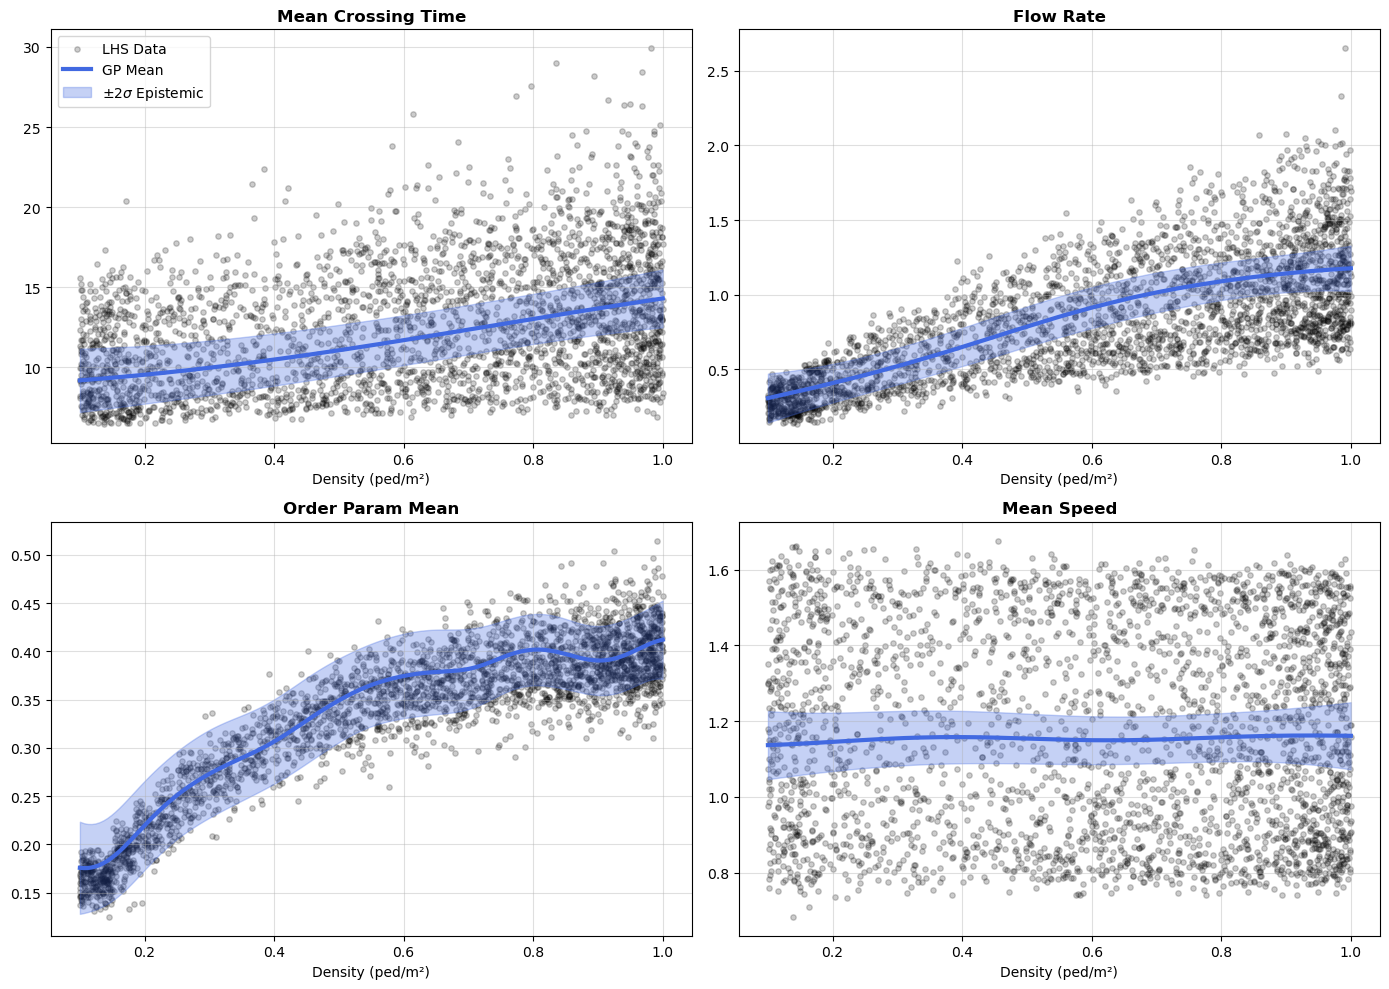

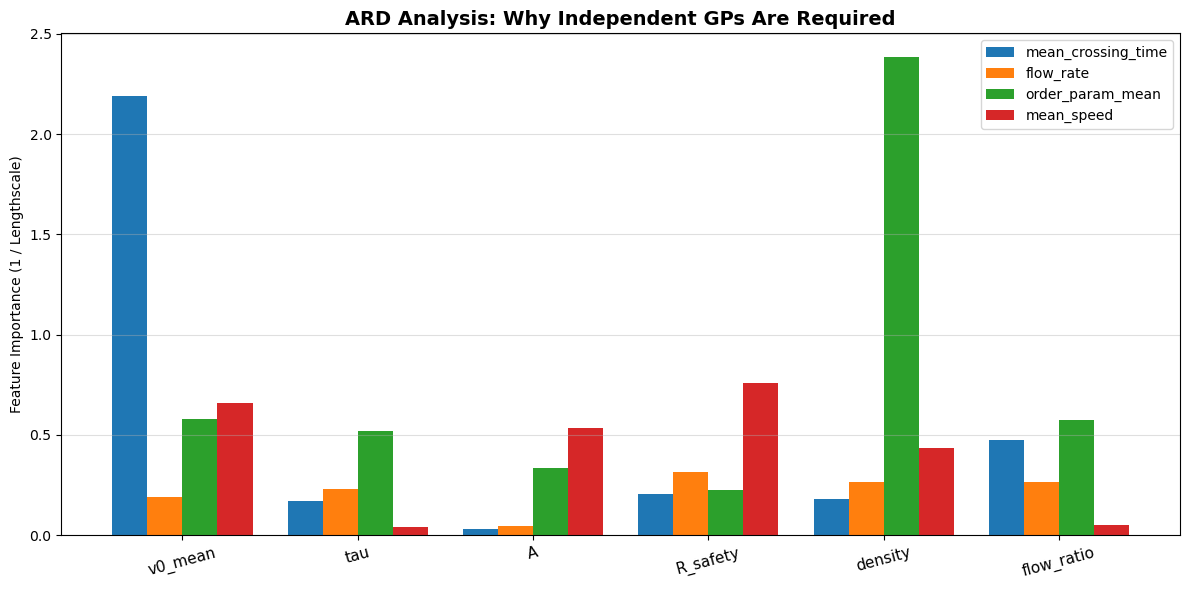

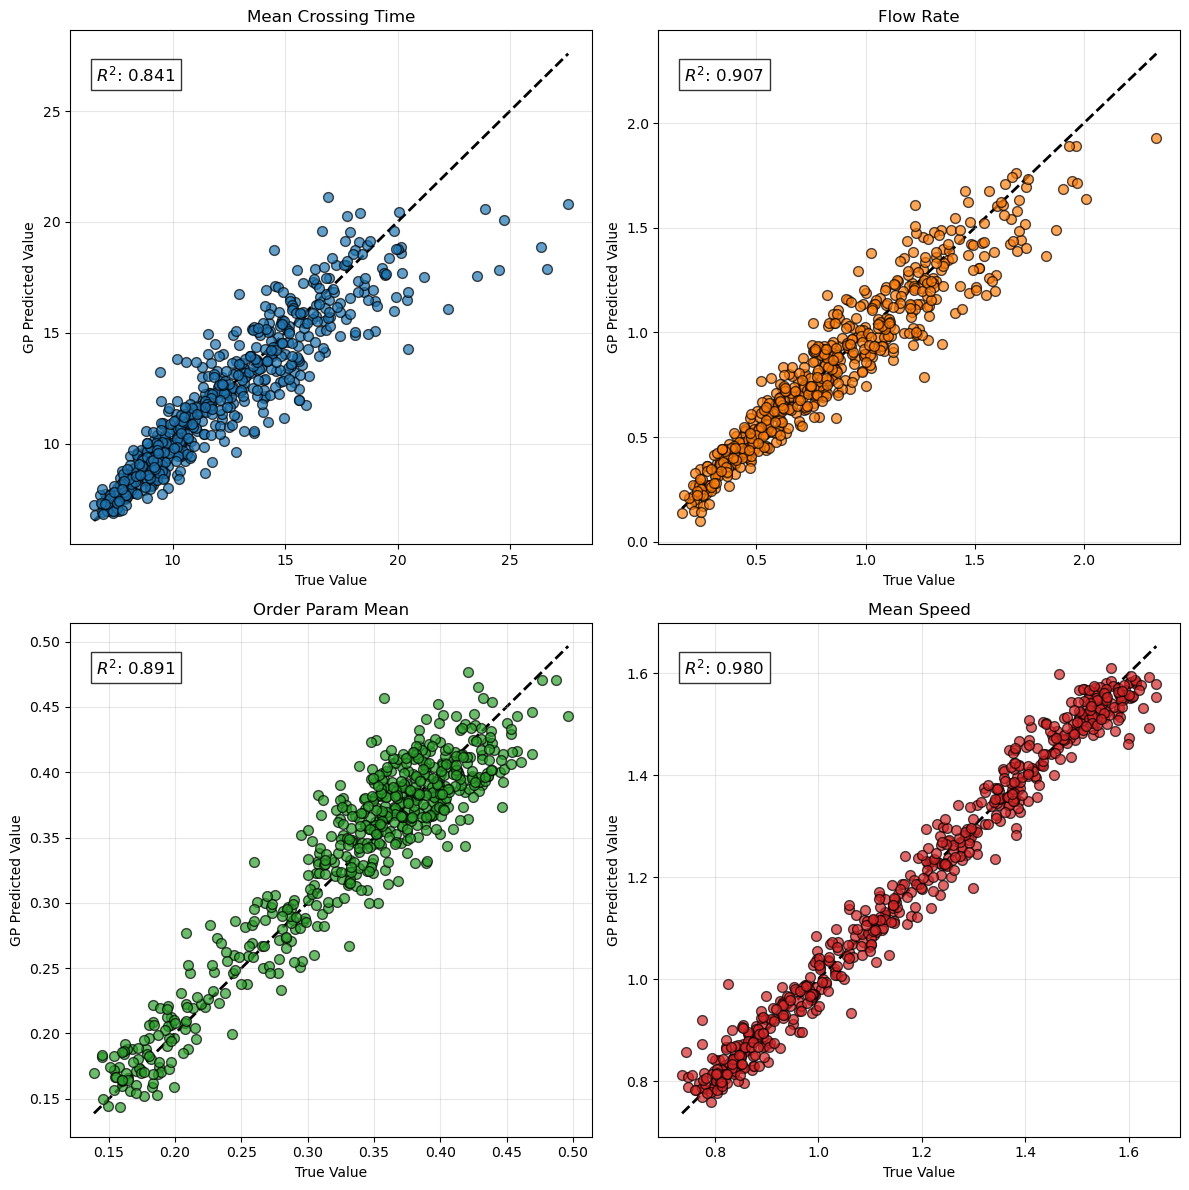

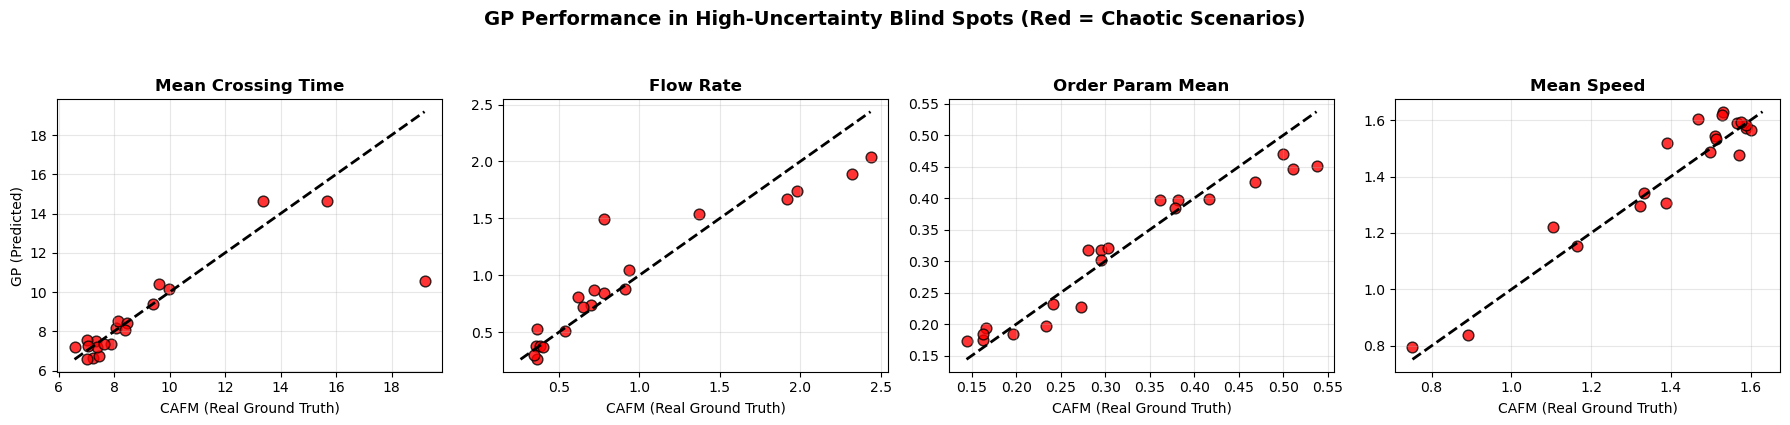

In [8]:
if __name__ == "__main__":
    DATA_PATH = r"D:\KIT\cafm_lhs_3000_active.npz"
    
    # 1. Train the models and get them back
    model_list, likelihood_list, scaler_X, scaler_Y, device, out_names = run_gpytorch_pipeline(DATA_PATH)
    
    # 2. Run the Benchmark Race (Random scenarios)
    run_cafm_vs_gp_benchmark(model_list, likelihood_list, scaler_X, scaler_Y, device, out_names)

    # 3. Find ALL chaotic points using the Radar (Saves to CSV)
    param_names = ["v0_mean", "tau", "A", "R_safety", "density", "flow_ratio"]
    chaotic_points = active_learning_radar(model_list, scaler_X, device, param_names, n_candidates=10000, percentile_threshold=80)
    
    # 4. Analyze the exact failure modes in the newly found chaotic zones
    analyze_blind_spots("active_learning_targets.csv", model_list, scaler_X, scaler_Y, device, out_names, top_k=20)